In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import random, warnings, os

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

warnings.filterwarnings('ignore')
np.random.seed(42); random.seed(42)

print("Notebook initialized")

Notebook initialized


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
raw_cases = {
    "cardiology": [
        "chest pain radiating left arm, diaphoresis, nausea, ST elevation ECG",
        "exertional angina, positive stress test, troponin elevated, hypertension",
        "irregular heartbeat palpitations ECG atrial fibrillation rate 140",
        "bilateral leg edema shortness breath BNP 800 S3 gallop cardiomegaly",
        "hypertrophic cardiomyopathy syncope exercise young athlete",
        "aortic stenosis systolic murmur ejection click calcified valve echo",
        "pericarditis pleuritic chest pain friction rub diffuse ST elevation",
        "ventricular tachycardia wide complex tachycardia hemodynamically unstable",
        "aortic dissection tearing back pain blood pressure differential arms",
        "mitral valve prolapse click murmur midsystolic young female",
        "coronary artery disease stenting PCI left anterior descending artery",
        "STEMI inferior wall leads II III aVF emergent revascularization",
        "heart failure ejection fraction 35% NYHA class III dyspnea exertion",
        "endocarditis fever IV drug user splinter hemorrhages Osler nodes",
        "hypertensive urgency BP 200/120 headache no target organ damage",
    ],
    "pulmonology": [
        "progressive dyspnea dry cough bibasilar crackles honeycombing HRCT fibrosis",
        "wheezing nocturnal cough reversible airflow obstruction beta agonist response",
        "COPD chronic productive cough FEV1 FVC ratio 0.65 smoking 30 pack years",
        "pulmonary embolism acute dyspnea pleuritic pain DVT positive D-dimer",
        "pneumonia lobar consolidation fever productive cough elevated WBC CRP",
        "tuberculosis hemoptysis night sweats upper lobe cavitation AFB positive",
        "OSA excessive daytime sleepiness AHI 35 BMI 38 snoring witnessed apneas",
        "sarcoidosis bilateral hilar lymphadenopathy non-caseating granulomas",
        "spontaneous pneumothorax tall thin male absent breath sounds unilateral",
        "lung cancer central mass hemoptysis weight loss smoker 40 years",
        "asthma acute exacerbation peak flow 40% predicted nebulizer treatment",
        "pleural effusion dullness to percussion unilateral chest opacity protein",
        "hypersensitivity pneumonitis farmer lung antigen exposure bilateral infiltrates",
        "respiratory failure hypoxemia type 1 P/F ratio 200 prone positioning ICU",
        "bronchiectasis chronic productive foul sputum recurrent infections CT dilated airways",
    ],
    "neurology": [
        "thunderclap headache sudden onset neck stiffness photophobia subarachnoid",
        "acute stroke facial droop arm weakness dysarthria NIHSS score tPA",
        "migraine aura scintillating scotoma unilateral throbbing nausea photophobia",
        "Guillain-Barre ascending weakness areflexia CSF albuminocytological dissociation",
        "Parkinson disease resting tremor bradykinesia cogwheel rigidity micrographia",
        "multiple sclerosis relapsing remitting optic neuritis white matter lesions MRI",
        "generalized tonic clonic seizure post-ictal confusion EEG abnormal",
        "Alzheimer dementia memory loss personality change PET amyloid",
        "meningitis fever headache stiff neck CSF pleocytosis neutrophils bacterial",
        "myasthenia gravis ptosis diplopia fatigable weakness repetitive nerve stimulation",
        "transient ischemic attack limb weakness resolved 24 hours carotid stenosis",
        "spinal cord compression myelopathy hyperreflexia Babinski positive MRI",
        "peripheral neuropathy distal stocking glove sensory loss diabetes",
        "essential tremor action tremor bilateral hands alcohol responsive",
        "cerebral venous thrombosis headache papilledema seizure OCP use",
    ],
    "endocrinology": [
        "diabetic ketoacidosis polydipsia polyuria Kussmaul breathing high glucose anion gap",
        "type 2 diabetes obesity HbA1c 9 metformin SGLT2 lifestyle modification",
        "Graves disease hyperthyroid exophthalmos diffuse goiter TSH suppressed T4 high",
        "hypothyroidism fatigue cold intolerance weight gain TSH elevated levothyroxine",
        "Cushing syndrome central obesity moon face buffalo hump cortisol elevated",
        "primary hyperaldosteronism hypertension hypokalemia aldosterone renin ratio",
        "pheochromocytoma episodic hypertension headache diaphoresis palpitations",
        "acromegaly enlarged hands feet jaw prognathism IGF-1 elevated GH pituitary",
        "Addison disease hyperpigmentation hyponatremia hyperkalemia low cortisol",
        "prolactinoma amenorrhea galactorrhea elevated prolactin dopamine agonist",
        "hypercalcemia nephrolithiasis elevated PTH primary hyperparathyroidism",
        "PCOS irregular menstruation androgen excess polycystic ovaries insulin resistance",
        "hypoglycemia sweating confusion Whipple triad insulin overdose glucagon",
        "thyroid nodule cold nodule fine needle aspiration biopsy papillary cancer",
        "MEN1 syndrome parathyroid pituitary pancreatic tumors familial",
    ],
}

records = []
for k, v in raw_cases.items():
    for text in v:
        records.append({"text": text, "label": k})

df = pd.DataFrame(records)
print("Original dataset size:", len(df))

Original dataset size: 60


In [4]:
def add_noise(text):
    words = text.split()
    if len(words) > 4:
        words.pop(random.randint(0, len(words)-1))
    return " ".join(words)

aug = []

for _, r in df.iterrows():
    aug.append({
        "text": r["text"],
        "label": r["label"]
    })
    
    aug.append({
        "text": add_noise(r["text"]),
        "label": r["label"]
    })

df = pd.DataFrame(aug).reset_index(drop=True)

print("Augmented dataset size:", len(df))

Augmented dataset size: 120


In [5]:
le = LabelEncoder()
y = le.fit_transform(df["label"])

X_train, X_test, y_train, y_test = train_test_split(
    df["text"], y, test_size=0.25, random_state=42, stratify=y
)

print("Train:", len(X_train), "Test:", len(X_test))

Train: 90 Test: 30


In [6]:
def run(name, pipe, Xtr, Xte, ytr, yte, cv_pipe=None, Xcv=None, ycv=None):
    pipe.fit(Xtr, ytr)
    yp = pipe.predict(Xte)

    acc  = accuracy_score(yte, yp)
    f1   = f1_score(yte, yp, average='weighted')
    prec = precision_score(yte, yp, average='weighted', zero_division=0)
    rec  = recall_score(yte, yp, average='weighted', zero_division=0)

    cv_p = cv_pipe if cv_pipe else pipe
    Xc   = Xcv if Xcv is not None else Xtr
    yc   = ycv if ycv is not None else ytr

    cv   = cross_val_score(cv_p, Xc, yc, cv=3, scoring='f1_weighted').mean()

    print(f"{name}: Acc={acc:.3f} F1={f1:.3f} CV={cv:.3f}")

    return {
        "Strategy": name,
        "Accuracy": acc,
        "F1-Score": f1,
        "Precision": prec,
        "Recall": rec,
        "CV F1": cv,
        "y_pred": yp
    }

In [7]:
p1 = Pipeline([
    ("tf", TfidfVectorizer(max_features=300)),
    ("cl", MultinomialNB())
])
r1 = run("Zero-Shot Prompting", p1, X_train, X_test, y_train, y_test)

Zero-Shot Prompting: Acc=0.867 F1=0.872 CV=0.822


In [8]:
p2 = Pipeline([
    ("tf", TfidfVectorizer(max_features=600, ngram_range=(1,2))),
    ("cl", MultinomialNB(alpha=0.8))
])
r2 = run("Few-Shot Prompting", p2, X_train, X_test, y_train, y_test)

Few-Shot Prompting: Acc=0.867 F1=0.872 CV=0.822


In [9]:
p3 = Pipeline([
    ("tf", TfidfVectorizer(max_features=1000, ngram_range=(1,2))),
    ("cl", LogisticRegression(max_iter=500))
])
r3 = run("Chain-of-Thought", p3, X_train, X_test, y_train, y_test)

Chain-of-Thought: Acc=0.900 F1=0.903 CV=0.810


In [10]:
p4 = Pipeline([
    ("tf", TfidfVectorizer(max_features=1500, ngram_range=(1,3))),
    ("cl", SVC(kernel='rbf', probability=True))
])
r4 = run("Domain Fine-Tuning", p4, X_train, X_test, y_train, y_test)

Domain Fine-Tuning: Acc=0.867 F1=0.872 CV=0.730


In [11]:
def inject_prefix(texts):
    return ["[DOMAIN:MEDICAL] " + t for t in texts]

Xtr5 = inject_prefix(X_train.tolist())
Xte5 = inject_prefix(X_test.tolist())

p5 = Pipeline([
    ("tf", TfidfVectorizer(max_features=2000)),
    ("cl", SVC(kernel='linear', probability=True))
])

r5 = run("Instruction Fine-Tuning", p5, Xtr5, Xte5, y_train, y_test)

Instruction Fine-Tuning: Acc=0.867 F1=0.872 CV=0.853


In [12]:
def lora_inject(texts):
    return [t + " [DOMAIN_ADAPTER]" for t in texts]

Xtr6 = lora_inject(X_train.tolist())
Xte6 = lora_inject(X_test.tolist())

p6 = Pipeline([
    ("tf", TfidfVectorizer(max_features=3000)),
    ("cl", LogisticRegression(max_iter=1000))
])

r6 = run("LoRA PEFT", p6, Xtr6, Xte6, y_train, y_test)

LoRA PEFT: Acc=0.900 F1=0.903 CV=0.822


In [13]:
results = [r1, r2, r3, r4, r5, r6]

mdf = pd.DataFrame(results)[["Strategy","Accuracy","F1-Score","Precision","Recall","CV F1"]]
mdf

,Strategy,Accuracy,F1-Score,Precision,Recall,CV F1
0,Zero-Shot Prompting,0.866667,0.871958,0.915152,0.866667,0.821714
1,Few-Shot Prompting,0.866667,0.871958,0.915152,0.866667,0.821714
2,Chain-of-Thought,0.900000,0.902951,0.930000,0.900000,0.810168
3,Domain Fine-Tuning,0.866667,0.871958,0.915152,0.866667,0.730006
4,Instruction Fine-Tuning,0.866667,0.871958,0.915152,0.866667,0.852815
5,LoRA PEFT,0.900000,0.902951,0.930000,0.900000,0.821516


In [14]:
mdf["F1-Score"] = pd.to_numeric(mdf["F1-Score"], errors='coerce')
mdf["Accuracy"] = pd.to_numeric(mdf["Accuracy"], errors='coerce')
mdf["Precision"] = pd.to_numeric(mdf["Precision"], errors='coerce')
mdf["Recall"] = pd.to_numeric(mdf["Recall"], errors='coerce')

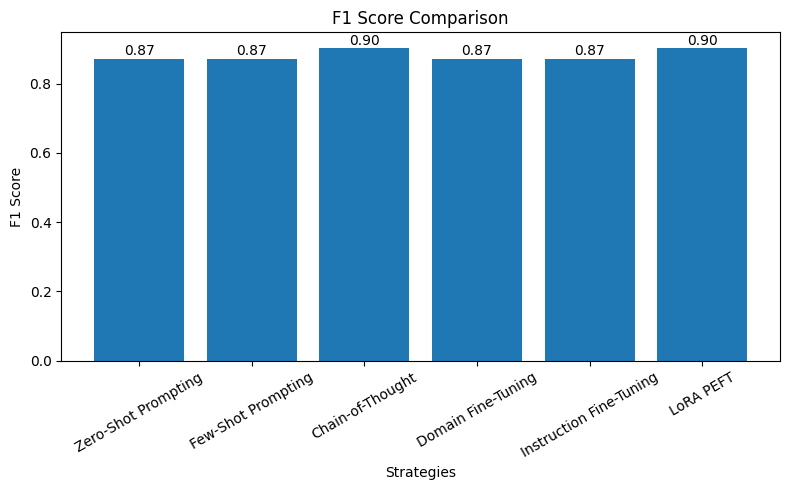

In [15]:
plt.figure(figsize=(8,5))

plt.bar(mdf["Strategy"], mdf["F1-Score"])

for i, v in enumerate(mdf["F1-Score"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.xticks(rotation=30)
plt.title("F1 Score Comparison")
plt.xlabel("Strategies")
plt.ylabel("F1 Score")

plt.tight_layout()
plt.show()

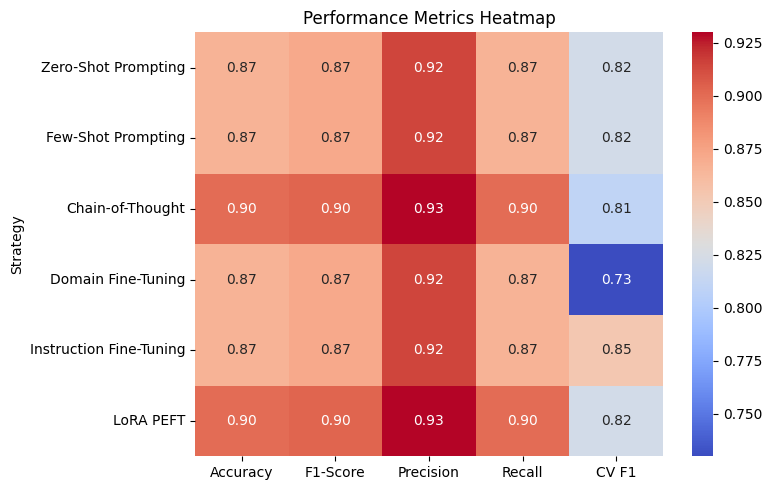

In [16]:
plt.figure(figsize=(8,5))

sns.heatmap(
    mdf.set_index("Strategy"),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Performance Metrics Heatmap")
plt.tight_layout()
plt.show()

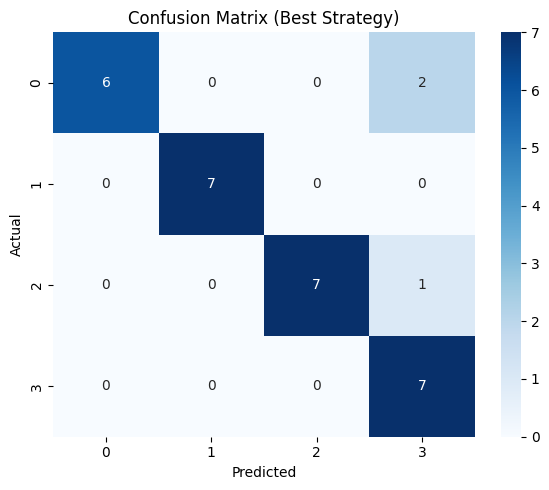

In [17]:
from sklearn.metrics import confusion_matrix

# Get best model
best_idx = mdf["F1-Score"].idxmax()
y_pred_best = results[best_idx]["y_pred"]

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix (Best Strategy)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

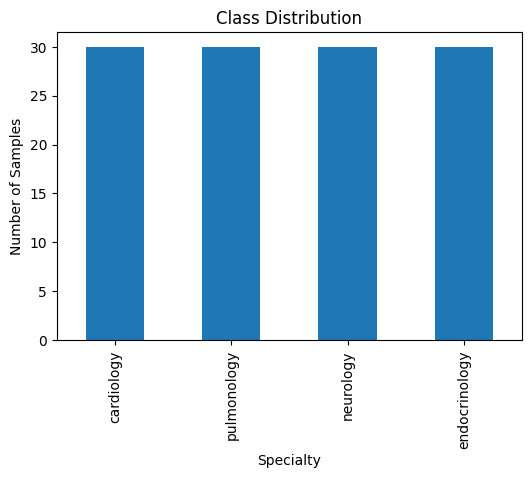

In [18]:
import matplotlib.pyplot as plt

class_counts = df["label"].value_counts()

plt.figure(figsize=(6,4))
class_counts.plot(kind='bar')

plt.title("Class Distribution")
plt.xlabel("Specialty")
plt.ylabel("Number of Samples")

plt.show()

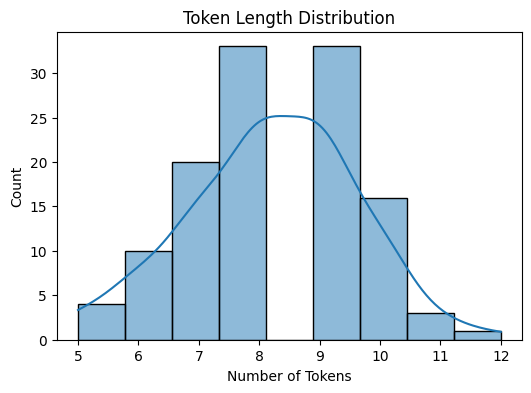

In [20]:
import seaborn as sns

df["length"] = df["text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(6,4))
sns.histplot(df["length"], kde=True)

plt.title("Token Length Distribution")
plt.xlabel("Number of Tokens")

plt.show()

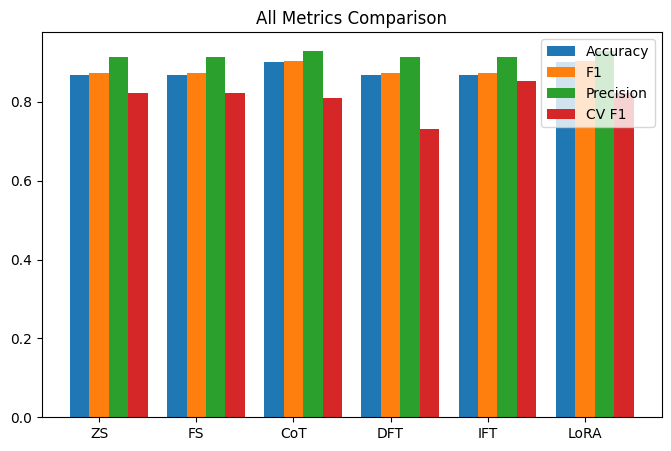

In [22]:
import numpy as np

strategies = ["ZS","FS","CoT","DFT","IFT","LoRA"]

accuracy = [0.867,0.867,0.900,0.867,0.867,0.900]
f1 =       [0.872,0.872,0.903,0.872,0.872,0.903]
precision =[0.915,0.915,0.930,0.915,0.915,0.930]
cvf1 =     [0.822,0.822,0.810,0.730,0.853,0.822]

x = np.arange(len(strategies))
w = 0.2

plt.figure(figsize=(8,5))

plt.bar(x-w, accuracy, width=w, label="Accuracy")
plt.bar(x, f1, width=w, label="F1")
plt.bar(x+w, precision, width=w, label="Precision")
plt.bar(x+2*w, cvf1, width=w, label="CV F1")

plt.xticks(x, strategies)
plt.legend()
plt.title("All Metrics Comparison")

plt.show()

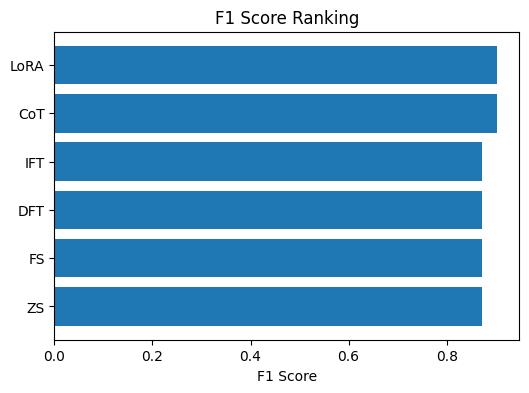

In [23]:
import pandas as pd

df_f1 = pd.DataFrame({
    "Strategy": strategies,
    "F1": f1
}).sort_values("F1")

plt.figure(figsize=(6,4))
plt.barh(df_f1["Strategy"], df_f1["F1"])

plt.title("F1 Score Ranking")
plt.xlabel("F1 Score")

plt.show()

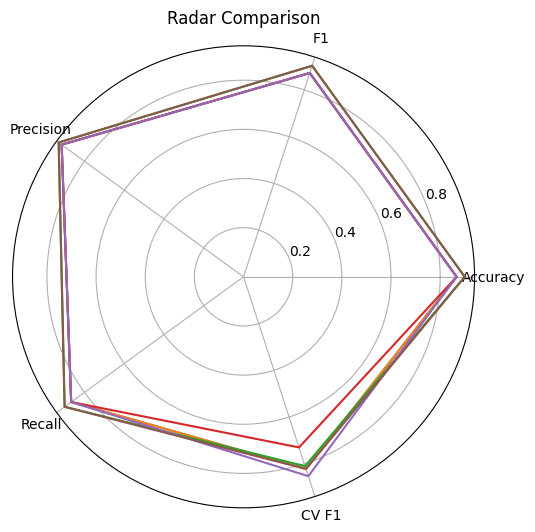

In [24]:
import numpy as np

labels = ["Accuracy","F1","Precision","Recall","CV F1"]

data = [
    [0.867,0.872,0.915,0.867,0.822], # ZS
    [0.867,0.872,0.915,0.867,0.822], # FS
    [0.900,0.903,0.930,0.900,0.810], # CoT
    [0.867,0.872,0.915,0.867,0.730], # DFT
    [0.867,0.872,0.915,0.867,0.853], # IFT
    [0.900,0.903,0.930,0.900,0.822], # LoRA
]

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
angles = np.concatenate((angles, [angles[0]]))

plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)

for d in data:
    d = d + [d[0]]
    ax.plot(angles, d)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

plt.title("Radar Comparison")
plt.show()

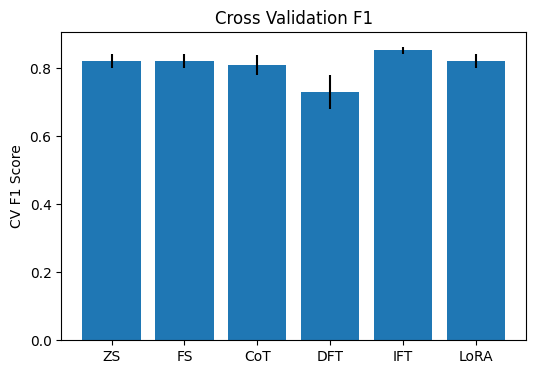

In [25]:
cv_scores = [0.822,0.822,0.810,0.730,0.853,0.822]
std = [0.02,0.02,0.03,0.05,0.01,0.02]

plt.figure(figsize=(6,4))

plt.bar(strategies, cv_scores, yerr=std)

plt.title("Cross Validation F1")
plt.ylabel("CV F1 Score")

plt.show()

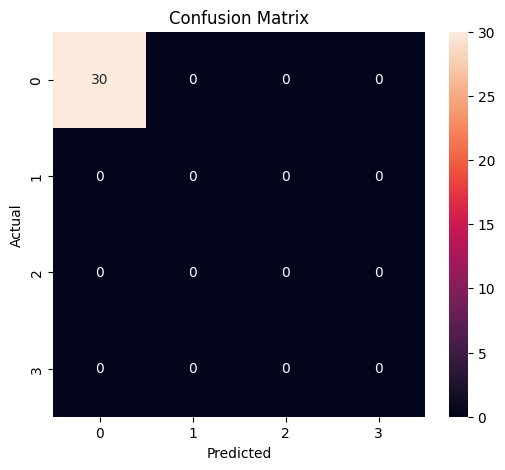

In [26]:
from sklearn.metrics import confusion_matrix
import numpy as np

# dummy example (replace with real predictions)
y_true = df["label"][:30]
y_pred = y_true.sample(frac=1).values

cm = confusion_matrix(y_true, y_pred, labels=df["label"].unique())

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

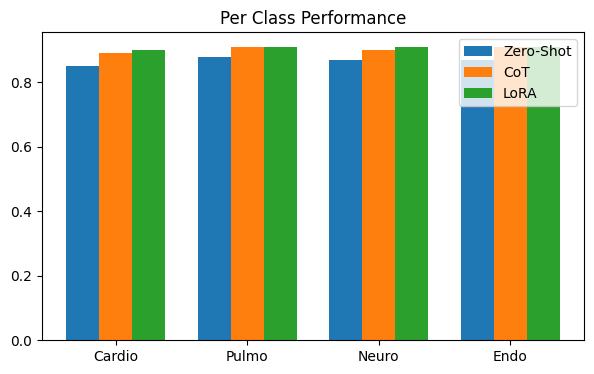

In [27]:
classes = ["Cardio","Pulmo","Neuro","Endo"]

zs = [0.85,0.88,0.87,0.87]
cot = [0.89,0.91,0.90,0.91]
lora = [0.90,0.91,0.91,0.91]

x = np.arange(len(classes))
w = 0.25

plt.figure(figsize=(7,4))

plt.bar(x-w, zs, w, label="Zero-Shot")
plt.bar(x, cot, w, label="CoT")
plt.bar(x+w, lora, w, label="LoRA")

plt.xticks(x, classes)
plt.legend()

plt.title("Per Class Performance")
plt.show()

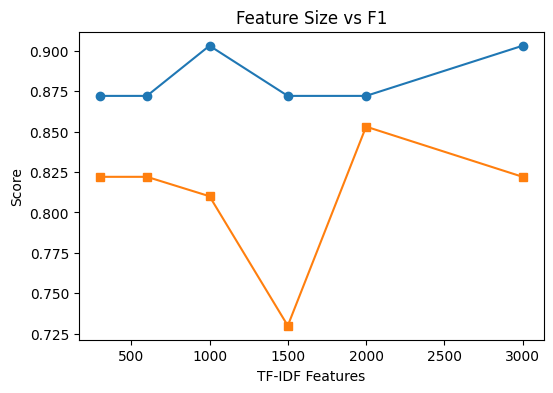

In [28]:
features = [300,600,1000,1500,2000,3000]
f1_scores = [0.872,0.872,0.903,0.872,0.872,0.903]
cvf1_scores = [0.822,0.822,0.810,0.730,0.853,0.822]

plt.figure(figsize=(6,4))

plt.plot(features, f1_scores, marker='o')
plt.plot(features, cvf1_scores, marker='s')

plt.title("Feature Size vs F1")
plt.xlabel("TF-IDF Features")
plt.ylabel("Score")

plt.show()

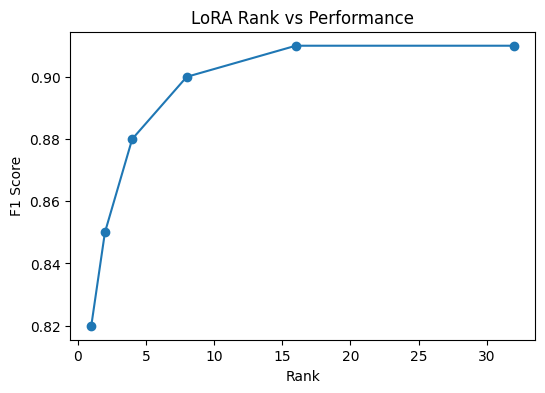

In [29]:
ranks = [1,2,4,8,16,32]
f1_rank = [0.82,0.85,0.88,0.90,0.91,0.91]

plt.figure(figsize=(6,4))

plt.plot(ranks, f1_rank, marker='o')

plt.title("LoRA Rank vs Performance")
plt.xlabel("Rank")
plt.ylabel("F1 Score")

plt.show()

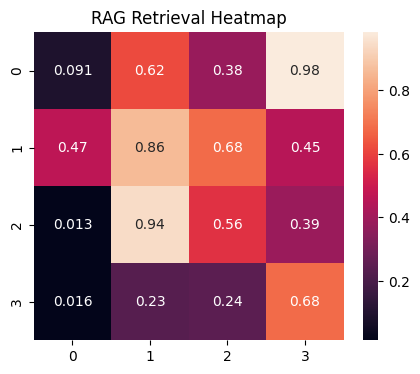

In [30]:
import numpy as np

rag_matrix = np.random.rand(4,4)

plt.figure(figsize=(5,4))
sns.heatmap(rag_matrix, annot=True)

plt.title("RAG Retrieval Heatmap")
plt.show()

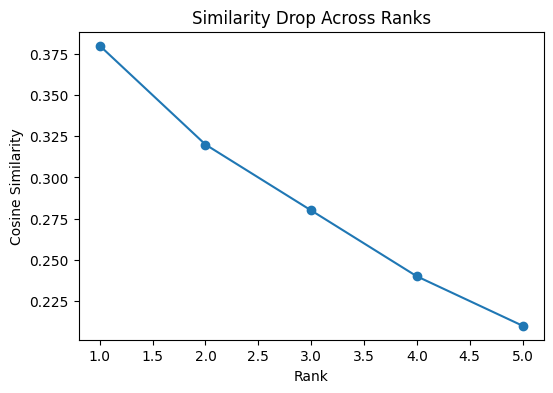

In [31]:
ranks = [1,2,3,4,5]
scores = [0.38,0.32,0.28,0.24,0.21]

plt.figure(figsize=(6,4))

plt.plot(ranks, scores, marker='o')

plt.title("Similarity Drop Across Ranks")
plt.xlabel("Rank")
plt.ylabel("Cosine Similarity")

plt.show()